In [5]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest

def game(graph, weights, top_k=50):
    n = len(graph)
    blocked = set()
    
    p1 = set()
    p2 = set()
    turn_p2 = False
    
    def get_candidates():
        candidates = []
        for v in graph:
            if v not in blocked:
                blocked_weight = sum(weights[u] for u in graph[v] if u not in blocked)
                score = weights[v] + blocked_weight
                candidates.append((score, v))
        candidates.sort(reverse=True)
        return [v for _, v in candidates[:top_k]]
    
    while True:
        candidates = get_candidates()
        if not candidates:
            break
        
        best_v = None
        best_score = float('-inf')
        
        for v in candidates:
            my_gain = weights[v]
            blocked_gain = sum(weights[u] for u in graph[v] if u not in blocked)
            
            new_blocked = blocked | {v} | set(graph[v])
            opp_moves = [u for u in graph if u not in new_blocked]
            opp_best = max([weights[u] for u in opp_moves], default=0)
            
            score = my_gain + blocked_gain - opp_best
            if score > best_score:
                best_score = score
                best_v = v
        
        if turn_p2:
            p2.add(best_v)
        else:
            p1.add(best_v)
        
        blocked.add(best_v)
        blocked.update(graph[best_v])
        
        turn_p2 = not turn_p2
    
    sum_p1 = sum(weights[v] for v in p1)
    sum_p2 = sum(weights[v] for v in p2)
    
    return sum_p1, sum_p2

def generate_random_graph(n, edge_prob=0.3):
    graph = {i: [] for i in range(n)}
    weights = {i: random.randint(1, 20) for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < edge_prob:
                graph[i].append(j)
                graph[j].append(i)
    return graph, weights

def measure_times(n_trials, n):
    times = []
    for _ in range(n_trials):
        graph, weights = generate_random_graph(n)
        start = time.time()
        game(graph, weights)
        end = time.time()
        times.append(end - start)
    times = np.array(times)
    mean_time = times.mean()
    std_time = times.std()
    last_time = times[-1]
    print(f"n={n}, Последний замер: {last_time:.6f}s, Среднее время: {mean_time:.6f}s, СКО: {std_time:.6f}s")
    return times, mean_time, std_time

sizes = [5, 10, 15, 20, 25, 100, 500, 1000, 2500, 5000]
mean_times = []
std_times = []

for n in sizes:
    times, mean_t, std_t = measure_times(n_trials=20, n=n)
    mean_times.append(mean_t)
    std_times.append(std_t)

plt.figure(figsize=(8,5))
mean_times = np.array(mean_times)
std_times = np.array(std_times)
plt.plot(sizes, mean_times, label='Среднее время')
plt.fill_between(sizes, mean_times-2*std_times, mean_times+2*std_times, color='orange', alpha=0.3, label='±2 СКО')
plt.xlabel('Размер графа n')
plt.ylabel('Время выполнения (с)')
plt.title('Зависимость времени выполнения от размера графа')
plt.legend()
plt.show()

times, mean_t, std_t = measure_times(n_trials=400, n=4000)
plt.figure(figsize=(7,4))
plt.hist(times, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (с)')
plt.ylabel('Частота')
plt.title('Гистограмма времени выполнения (n=4000)')
plt.show()

stat, p_value = normaltest(times)
print(f"Тест на нормальность: статистика={stat:.3f}, p-value={p_value:.3f}")
if p_value > 0.05:
    print("Можно принять гипотезу о нормальном распределении времени")
else:
    print("Гипотеза о нормальном распределении времени отвергается")

avg_time_ms = mean_t * 1000
print(f"Среднее время выполнения для n=4000 ≈ {avg_time_ms:.2f} мс")

n=5, Последний замер: 0.000029s, Среднее время: 0.000026s, СКО: 0.000009s
n=10, Последний замер: 0.000060s, Среднее время: 0.000069s, СКО: 0.000016s
n=15, Последний замер: 0.000096s, Среднее время: 0.000125s, СКО: 0.000049s
n=20, Последний замер: 0.000150s, Среднее время: 0.000169s, СКО: 0.000040s
n=25, Последний замер: 0.000243s, Среднее время: 0.000219s, СКО: 0.000028s
n=100, Последний замер: 0.001647s, Среднее время: 0.001727s, СКО: 0.000180s
n=500, Последний замер: 0.018548s, Среднее время: 0.018429s, СКО: 0.000501s
n=1000, Последний замер: 0.060636s, Среднее время: 0.061327s, СКО: 0.001593s


KeyboardInterrupt: 

n=5, Последний замер: 0.000019s, Среднее время: 0.000024s, СКО: 0.000008s
n=10, Последний замер: 0.000041s, Среднее время: 0.000051s, СКО: 0.000006s
n=15, Последний замер: 0.000107s, Среднее время: 0.000096s, СКО: 0.000011s
n=20, Последний замер: 0.000147s, Среднее время: 0.000157s, СКО: 0.000021s
n=25, Последний замер: 0.000323s, Среднее время: 0.000200s, СКО: 0.000036s
n=100, Последний замер: 0.001393s, Среднее время: 0.002051s, СКО: 0.001468s
n=500, Последний замер: 0.019429s, Среднее время: 0.019241s, СКО: 0.000533s
n=1000, Последний замер: 0.062798s, Среднее время: 0.062693s, СКО: 0.001283s


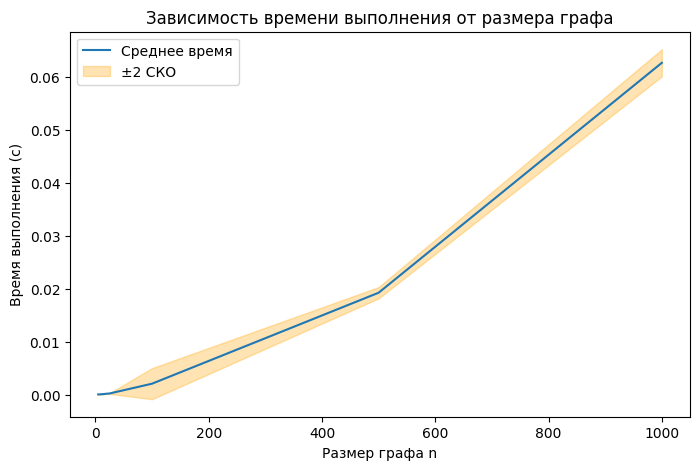

n=100, Последний замер: 0.001366s, Среднее время: 0.001566s, СКО: 0.000199s


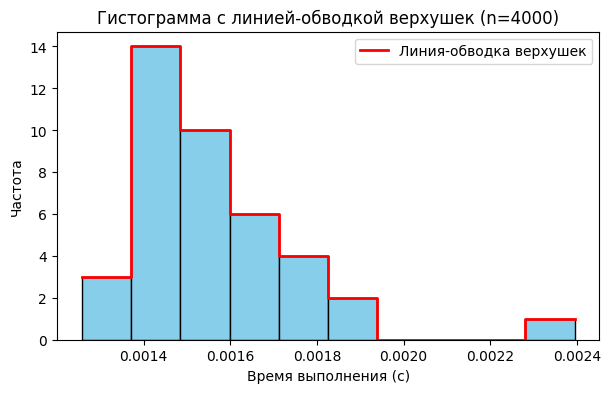

Тест на нормальность: статистика=30.019, p-value=0.000
Гипотеза о нормальном распределении времени отвергается
Chi2 статистика (Weibull): 16.742
p-value (Weibull): 0.005
Гипотеза о распределении Вейбулла отвергается
Среднее время выполнения для n=4000 ≈ 1.57 мс


In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import normaltest, weibull_min, chisquare

def game(graph, weights, top_k=50):
    n = len(graph)
    blocked = set()
    p1 = set()
    p2 = set()
    turn_p2 = False
    def get_candidates():
        candidates = []
        for v in graph:
            if v not in blocked:
                blocked_weight = sum(weights[u] for u in graph[v] if u not in blocked)
                score = weights[v] + blocked_weight
                candidates.append((score, v))
        candidates.sort(reverse=True)
        return [v for _, v in candidates[:top_k]]
    while True:
        candidates = get_candidates()
        if not candidates:
            break
        best_v = None
        best_score = float('-inf')
        for v in candidates:
            my_gain = weights[v]
            blocked_gain = sum(weights[u] for u in graph[v] if u not in blocked)
            new_blocked = blocked | {v} | set(graph[v])
            opp_moves = [u for u in graph if u not in new_blocked]
            opp_best = max([weights[u] for u in opp_moves], default=0)
            score = my_gain + blocked_gain - opp_best
            if score > best_score:
                best_score = score
                best_v = v
        if turn_p2:
            p2.add(best_v)
        else:
            p1.add(best_v)
        blocked.add(best_v)
        blocked.update(graph[best_v])
        turn_p2 = not turn_p2
    sum_p1 = sum(weights[v] for v in p1)
    sum_p2 = sum(weights[v] for v in p2)
    return sum_p1, sum_p2

def generate_random_graph(n, edge_prob=0.3):
    graph = {i: [] for i in range(n)}
    weights = {i: random.randint(1, 20) for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < edge_prob:
                graph[i].append(j)
                graph[j].append(i)
    return graph, weights

def measure_times(n_trials, n):
    times = []
    for _ in range(n_trials):
        graph, weights = generate_random_graph(n)
        start = time.time()
        game(graph, weights)
        end = time.time()
        times.append(end - start)
    times = np.array(times)
    mean_time = times.mean()
    std_time = times.std()
    last_time = times[-1]
    print(f"n={n}, Последний замер: {last_time:.6f}s, Среднее время: {mean_time:.6f}s, СКО: {std_time:.6f}s")
    return times, mean_time, std_time

sizes = [5, 10, 15, 20, 25, 100, 500, 1000]
mean_times = []
std_times = []

for n in sizes:
    times, mean_t, std_t = measure_times(n_trials=20, n=n)
    mean_times.append(mean_t)
    std_times.append(std_t)

plt.figure(figsize=(8,5))
mean_times = np.array(mean_times)
std_times = np.array(std_times)
plt.plot(sizes, mean_times, label='Среднее время')
plt.fill_between(sizes, mean_times-2*std_times, mean_times+2*std_times, color='orange', alpha=0.3, label='±2 СКО')
plt.xlabel('Размер графа n')
plt.ylabel('Время выполнения (с)')
plt.title('Зависимость времени выполнения от размера графа')
plt.legend()
plt.show()

times, mean_t, std_t = measure_times(n_trials=400, n=4000)
plt.figure(figsize=(7,4))
plt.hist(times, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (с)')
plt.ylabel('Частота')
plt.title('Гистограмма времени выполнения (n=4000)')
plt.show()

stat, p_value = normaltest(times)
print(f"Тест на нормальность: статистика={stat:.3f}, p-value={p_value:.3f}")
if p_value > 0.05:
    print("Можно принять гипотезу о нормальном распределении времени")
else:
    print("Гипотеза о нормальном распределении времени отвергается")

shape, loc, scale = weibull_min.fit(times, floc=0)
observed, bin_edges = np.histogram(times, bins=int(np.sqrt(len(times))))
cdf_vals = weibull_min.cdf(bin_edges, shape, loc=loc, scale=scale)
expected_probs = np.diff(cdf_vals)
expected = expected_probs * len(times)
expected = expected * (len(times) / expected.sum())
chi2_stat, p_value_chi2 = chisquare(observed, expected)
print(f"Chi2 статистика (Weibull): {chi2_stat:.3f}")
print(f"p-value (Weibull): {p_value_chi2:.3f}")
if p_value_chi2 > 0.05:
    print("Можно принять гипотезу о распределении Вейбулла")
else:
    print("Гипотеза о распределении Вейбулла отвергается")

avg_time_ms = mean_t * 1000
print(f"Среднее время выполнения для n=4000 ≈ {avg_time_ms:.2f} мс")